In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

df = pd.read_csv(
    "../data/processed/model_dataset.csv"
)
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66961 entries, 0 to 66960
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   readmitted_30d             66961 non-null  int64  
 1   length_of_stay             66961 non-null  int64  
 2   prior_admissions           66961 non-null  int64  
 3   days_since_last_admission  66961 non-null  float64
 4   chronic_burden             66961 non-null  int64  
 5   bene_sex_ident_cd          1699 non-null   float64
 6   bene_race_cd               1699 non-null   float64
 7   clm_utlztn_day_cnt         66961 non-null  float64
dtypes: float64(4), int64(4)
memory usage: 4.1 MB
None


,readmitted_30d,length_of_stay,prior_admissions,days_since_last_admission,chronic_burden,bene_sex_ident_cd,bene_race_cd,clm_utlztn_day_cnt
0,0,1,0,-1.0,0,NaN,NaN,0.0
1,0,12,1,60.0,0,NaN,NaN,12.0
2,0,3,2,45.0,0,NaN,NaN,3.0
3,0,4,3,93.0,0,NaN,NaN,4.0
4,0,4,0,-1.0,0,NaN,NaN,4.0


In [21]:
df["readmitted_30d"].value_counts()

readmitted_30d
0    58523
1     8438
Name: count, dtype: int64

In [22]:
y = df["readmitted_30d"]
X = df.drop(columns=["readmitted_30d"])

categorical_features = [
    "bene_sex_ident_cd",
    "bene_race_cd"
]

numerical_features = [
    "length_of_stay",
    "prior_admissions",
    "days_since_last_admission",
    "chronic_burden",
    "clm_utlztn_day_cnt"
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [24]:
log_reg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

log_reg_pipeline.fit(X_train, y_train)

y_pred_log = log_reg_pipeline.predict(X_test)

y_prob_log = log_reg_pipeline.predict_proba(X_test)[:, 1]

In [25]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [26]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                eval_metric="logloss",
                random_state=42
            )
        )
    ]
)

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)

y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

In [27]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)

    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)

    ],
    "F1": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)

    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.650190,0.161356,0.422986,0.233601,0.570750
1,Random Forest,0.733294,0.157455,0.256517,0.195133,0.532686
2,XGBoost,0.872023,0.250000,0.007701,0.014943,0.572351


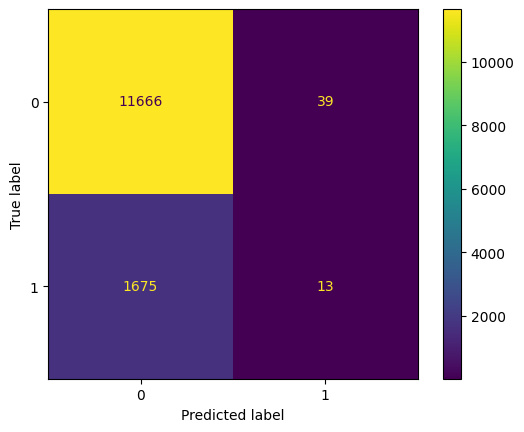

In [28]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb
)

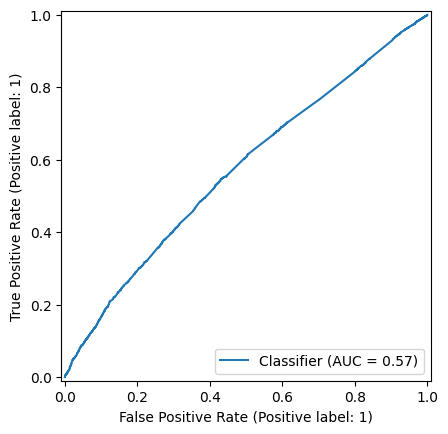

In [29]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb
)

In [30]:
joblib.dump(
    xgb_pipeline,
    "../models/xgb_readmission_model.pkl"
)

['../models/xgb_readmission_model.pkl']

In [31]:
results.to_csv(
    "../reports/metrics/model_results.csv",
    index=False
)